Importing Libraries and loading data


In [8]:
!pip install openpyxl

In [2]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------------------ --------- 6.0/8.0 MB 37.0 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 37.4 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 37.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 13.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -------- ------------------------------- 7.9/36.5 MB 37.4 MB/s eta 0:00:01
   ---------------- ----------------------- 15.5/36.5 MB 36.0 MB/s eta 0:00:01
   ------------------------- -------------- 23.1/36.5 MB 35.6 MB/s eta 0:00:01
   -------------------------------- ------- 30.1/36.5 MB 35.5 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 35.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 35.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 35.6 MB/s eta 0:00:01
 

In [3]:
import sklearn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib


In [10]:
file_path = r"C:\Users\Siddharth\Desktop\python ml churn\Prediction_data.xlsx"

In [11]:
sheet_name = 'Churn_Data'

In [17]:
data = pd.read_excel(file_path, sheet_name = 'Churn_data')

In [19]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,12052-PUN,Female,33,No,Punjab,11,31,NaN,Yes,Yes,...,Bank Withdrawal,115.000000,7396.149902,0.0,0,2972.159912,10368.309570,Stayed,Others,Others
1,12069-UTT,Female,30,Yes,Uttar Pradesh,10,14,Deal 4,Yes,No,...,Bank Withdrawal,59.650002,683.250000,0.0,0,232.539993,915.789978,Stayed,Others,Others
2,12079-MAH,Female,73,Yes,Maharashtra,2,4,NaN,Yes,No,...,Bank Withdrawal,79.900002,260.899994,0.0,0,8.940000,269.839996,Churned,Price,Price too high
3,12112-MAD,Female,27,No,Madhya Pradesh,14,4,Deal 5,Yes,No,...,Credit Card,20.450001,150.750000,0.0,0,40.880001,191.630005,Stayed,Others,Others
4,12118-TAM,Female,23,No,Tamil Nadu,7,3,Deal 2,Yes,Yes,...,Bank Withdrawal,85.550003,5084.649902,0.0,0,407.690002,5492.339844,Churned,Competitor,Competitor offered more data


In [20]:
#Data Processing

# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
#Training our Model by Random_forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Confusion Matrix:
[[813  66]
 [114 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       879
           1       0.76      0.65      0.70       323

    accuracy                           0.85      1202
   macro avg       0.82      0.79      0.80      1202
weighted avg       0.85      0.85      0.85      1202



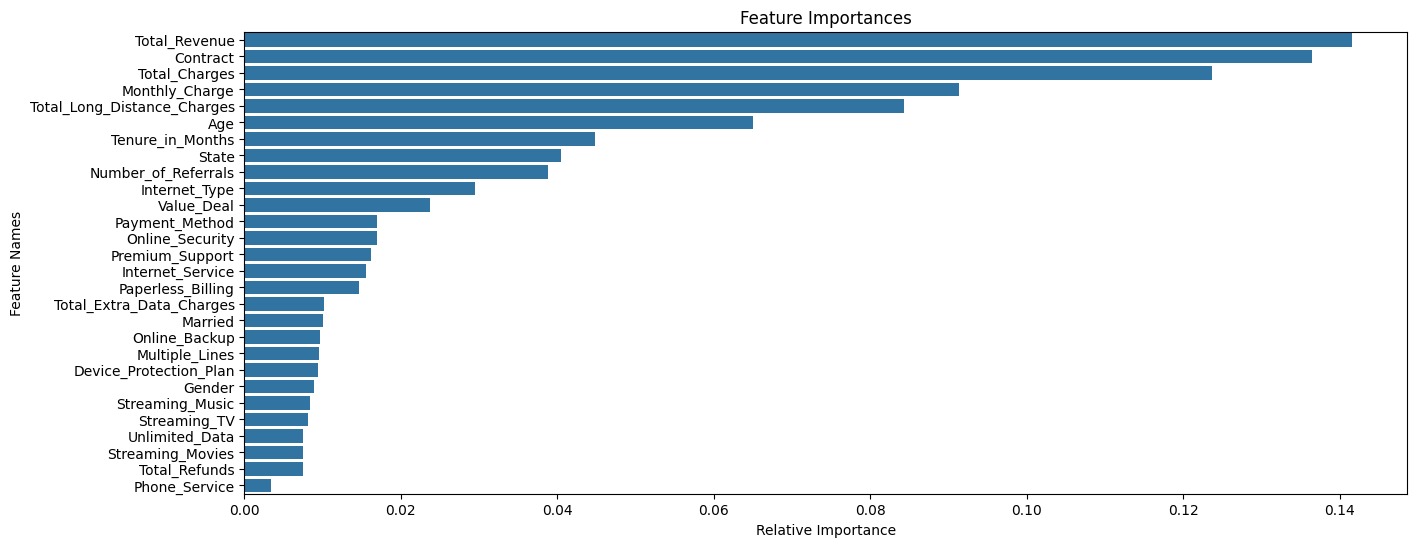

In [23]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()


In [24]:
# Define the path to the Joiner Data Excel file
file_path = r"C:\Users\Siddharth\Desktop\python ml churn\Prediction_data.xlsx"

# Define the sheet name to read data from
sheet_name = 'Join_data'

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

# Encode categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the results
original_data.to_csv(r"C:\Users\Siddharth\Desktop\python ml churn\Predictions.csv", index=False)


  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   12056-WES    Male   27      No  West Bengal                    2   
1   12136-RAJ  Female   25     Yes    Rajasthan                    2   
2   12257-ASS  Female   39      No        Assam                    9   
3   17597-HAR  Female   33     Yes      Haryana                    2   
4   21642-TEL    Male   60     Yes    Telangana                   12   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                20        NaN           Yes             No  ...   
1                35        NaN           Yes             No  ...   
2                 1        NaN           Yes             No  ...   
3                 6     Deal 5            No             No  ...   
4                29        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      90.400002    268.450012           0.0   
1  Bank Withdrawal      19.9